In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
df = pd.read_csv('netflix_titles.csv')

print("Shape:", df.shape)

df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


np.int64(0)

In [9]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
#1. The dataset contains 8807 Netflix titles
#2. It includes Movies and TV Shows
#3. Information such as country, rating, genre and release year is available
#4. Some records contain missing values in director, cast and country columns
#5. The dataset helps analyze Netflix content trends globally

In [15]:
# remove duplicates
df = df.drop_duplicates()

#filling values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

print(df['date_added'].head(10))

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
5    September 24, 2021
6    September 24, 2021
7    September 24, 2021
8    September 24, 2021
9    September 24, 2021
Name: date_added, dtype: object


In [16]:
df['date_added'].head(20)

,date_added
0,"September 25, 2021"
1,"September 24, 2021"
2,"September 24, 2021"
3,"September 24, 2021"
4,"September 24, 2021"
5,"September 24, 2021"
6,"September 24, 2021"
7,"September 24, 2021"
8,"September 24, 2021"
9,"September 24, 2021"


In [17]:
df['date_added'].dtype

dtype('O')

In [18]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

In [19]:
df['date_added'].isnull().sum()

np.int64(88)

In [20]:
df = df.dropna(subset=['date_added'])

df['year_added'] = df['date_added'].dt.year

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [21]:
#1. Duplicate rows were removed
#2. Missing director values were replaced with "Unknown
#3. Missing cast values were replaced with Unknown
#4. Missing country values were replaced with Unknown
#5. date_added was converted into datetime format for time analysis

In [22]:
#How many Movies and TV Shows are there on Netflix

df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2578


In [23]:
#Which countries have the most Netflix content

df['country'].value_counts().head(10)

,count
country,
United States,2778
India,971
Unknown,827
United Kingdom,403
Japan,241
South Korea,195
Canada,173
Spain,141
France,122


In [ ]:
#Which year did Netflix add the most content
df['year_added'].value_counts().sort_index()

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,10
2014,23
2015,73
2016,418


In [24]:
#What are the most common content ratings
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index()

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,10
2014,23
2015,73
2016,418


In [25]:
#Which genres are most popular on Netflix?
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3183
TV-14,2133
TV-PG,838
R,799
PG-13,490
TV-Y7,330
TV-Y,300
PG,287
TV-G,212


In [26]:
#Which genres are most popular on Netflix?
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Children & Family Movies,215
Kids' TV,212
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


In [35]:
#Top Directors on Netflix
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

print(top_directors)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


In [34]:
#Top Actors on Netflix
top_actors = (
    df[df['cast'] != 'Unknown']['cast']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

print(top_actors)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Rupa Bhimani        31
Takahiro Sakurai    31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64


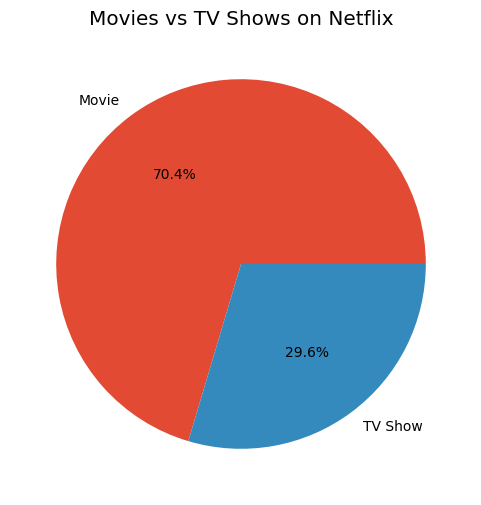

In [39]:
plt.figure(figsize=(6,6))

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('')
plt.show()

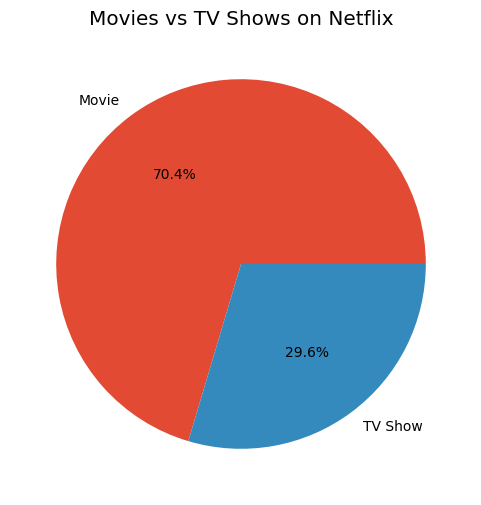

In [38]:
plt.figure(figsize=(6,6))

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('')
plt.show()

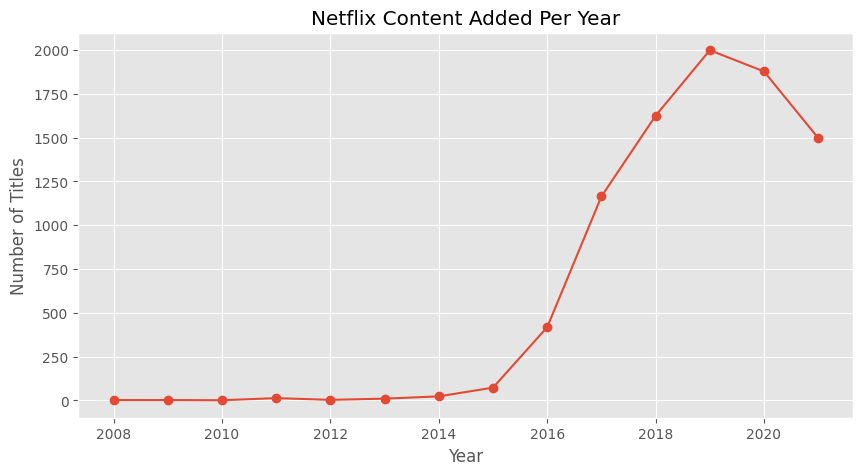

In [37]:
content_per_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    content_per_year.index,
    content_per_year.values,
    marker='o'
)

plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

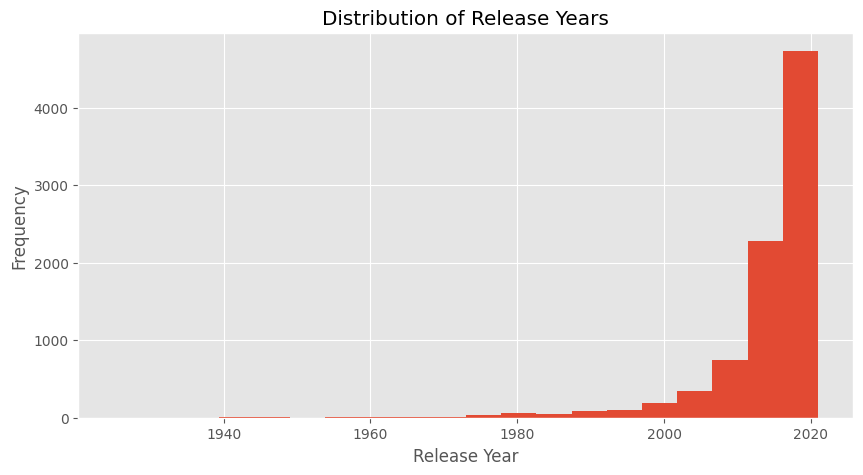

In [36]:
plt.figure(figsize=(10,5))

plt.hist(
    df['release_year'],
    bins=20
)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

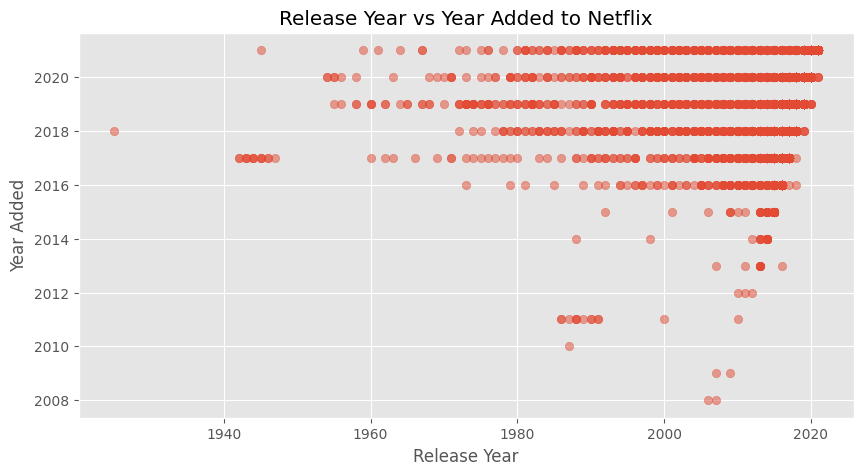

In [40]:
plt.figure(figsize=(10,5))

plt.scatter(
    df['release_year'],
    df['year_added'],
    alpha=0.5
)

plt.title('Release Year vs Year Added to Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added')

plt.show()

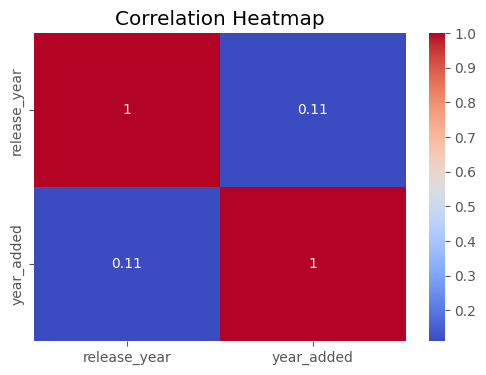

In [41]:
numeric_df = df[['release_year', 'year_added']]

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

1. Movies constitute a significantly larger portion of Netflix's catalog than TV Shows, indicating Netflix's strong focus on movie content.

2. The United States is the leading contributor of content on Netflix, followed by several other countries with much smaller shares.

3. Netflix experienced rapid content growth after 2015, with the number of titles added increasing sharply each year.

4. TV-MA is the most common content rating, suggesting that a large portion of Netflix content is targeted toward mature audiences.

5. Drama and international content genres appear most frequently, highlighting Netflix's emphasis on diverse global entertainment.

CONCLUSION
This project analyzed the Netflix Movies and TV Shows dataset using Python, Pandas, Matplotlib, and Seaborn. Data cleaning was performed to handle missing values and improve data quality. Seven exploratory data analysis questions were answered and six visualizations were created to understand content distribution and trends. The analysis revealed significant growth in Netflix's content library, a strong dominance of movies, and the importance of international content. These findings provide useful insights into Netflix's content strategy and global expansion.